In [1]:
%load_ext autoreload
%autoreload 2
from gen_img4pub import (
    imgen
)
from matplotlib import pyplot as plt
from useful import (fullax, savepng,CropWindow)

imagingPhase package loaded
0
phase uploaded
phase calculated
1
phase uploaded
phase calculated
2
phase uploaded
phase calculated
3
phase uploaded
phase calculated
4
phase uploaded
phase calculated


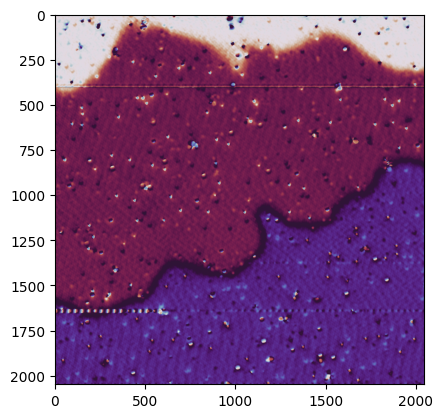

In [3]:
imgen.kmap(0,0,1)

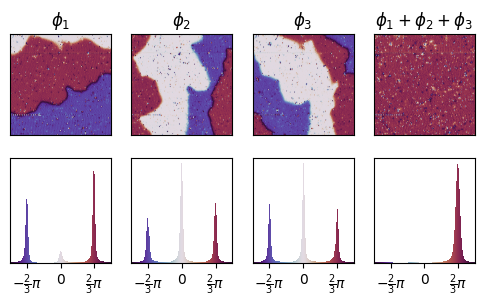

In [3]:
from useful import color_histogram
import numpy as np
u = np.pi*(2/3)
phi1 = -imgen.phiPrinters[0].phase[1]+u
phi2 = -imgen.phiPrinters[0].phase[0]
phi3 = -imgen.phiPrinters[0].phase[2]
phis = [phi1,phi2,phi3,phi1+phi2+phi3]
dfphase = imgen.dfphase()
phis = list(map(dfphase['arrfcn'][1],phis))
cmap = dfphase['cmap'][1]
msb,nsb = 2,4
fig,axs = plt.subplots(msb,nsb,figsize=(6,3))
phi_tns = [r'$\phi_1$',r'$\phi_2$',r'$\phi_3$',r'$\phi_1+\phi_2+\phi_3$']
for jsb,phi,tn in zip(range(nsb),phis,phi_tns):
    plt.sca(axs[0,jsb])
    plt.imshow(phi,cmap=cmap)
    plt.xticks([])
    plt.yticks([])
    plt.title(tn)
    plt.sca(axs[1,jsb])
    color_histogram(phi.flatten(),cmap=cmap)
    plt.xticks([-u,0,u])
    plt.gca().set_xticklabels([r'$-\frac{2}{3}\pi$', '0', r'$\frac{2}{3}\pi$'])
fig.savefig('assets/E03_phi123_v0.svg')
fig.savefig('assets/E03_phi123_v0.png')

In [5]:
xlimylim_DVR = ((560,690),(1310,1440))
xlimylim_DVL = ((1860,1990),(260,390))
dw_r = (1142,1496)
dw_g= (1708,202)
dw_b = (1352,173)

cw_vr = CropWindow()
cw_vr.set_xlimylim(*xlimylim_DVR)
cw_vl = CropWindow()
cw_vl.set_xlimylim(*xlimylim_DVL)
print(cw_vl,cw_vr)
cw_v = [cw_vr,cw_vl]
cw_r = CropWindow()
cw_r.set_by_anchor(dw_r,100)
cw_g = CropWindow()
cw_g.set_by_anchor(dw_g,100)
cw_b = CropWindow()
cw_b.set_by_anchor(dw_b,100)
cw_all = [cw_r,cw_g,cw_b,cw_vr,cw_vl]
cw_clrs= ['r','g','b',CLR_NODE[0,:],CLR_NODE[1,:]]

<useful.CropWindow object at 0x000001E8801F3230> <useful.CropWindow object at 0x000001E83CFF4200>


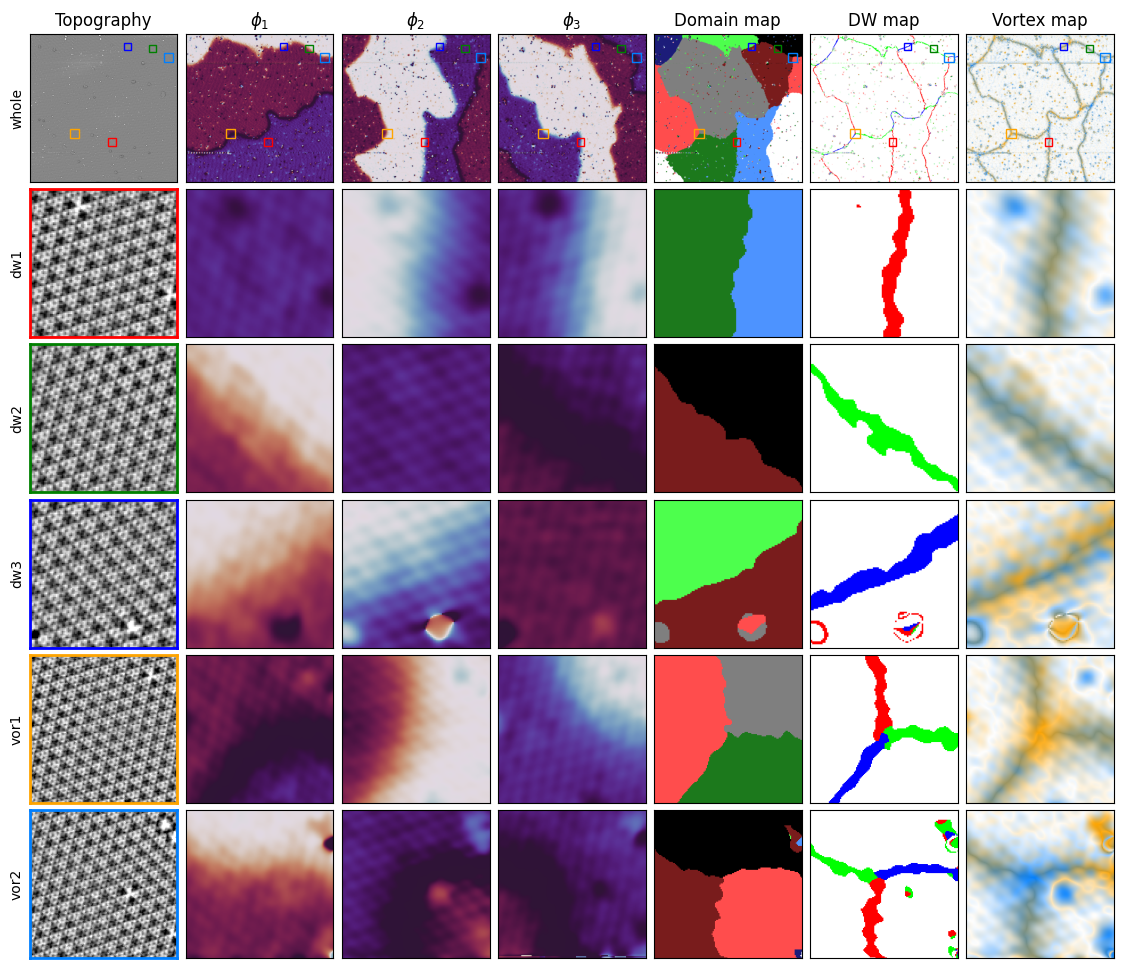

In [ ]:
from crypy_examples.dwn_toon import CLR_NODE
msb,nsb = 6,7
nm_rows = ['whole','dw1','dw2','dw3','vor1','vor2']
nm_cols = ['Topography',r'$\phi_1$',r'$\phi_2$',r'$\phi_3$'
           ,'Domain map','DW map','Vortex map']
fig,axs = plt.subplots(msb,nsb,figsize=(14,12))
fig.subplots_adjust(hspace=0.05, wspace=0.05)
idt = 0
def vis_cbox():
    for cw,clr in zip(cw_all,cw_clrs):
        cw.ax_cropbox(ls='-',ec=clr)
def box_edge(ax,clr,thick):
    for spine in ax.spines.values():
        spine.set_edgecolor(clr)
        spine.set_linewidth(thick)       
for isb in range(msb):    
    plt.sca(axs[isb,0]);imgen.topo(idt,cmap='gray')
    plt.sca(axs[isb,1]);imgen.kmap(idt,0,1)
    plt.sca(axs[isb,2]);imgen.kmap(idt,1,1)
    plt.sca(axs[isb,3]);imgen.kmap(idt,2,1)
    plt.sca(axs[isb,4]);imgen.domain(idt)
    plt.sca(axs[isb,5]);imgen.dw(idt)
    plt.sca(axs[isb,6]);imgen.vertex(idt)

for ax in axs.flat:
    plt.sca(ax)
    # box_edge(ax,'k',1)
    ax.set_xticks([])
    ax.set_yticks([])   
    ax.axis('on') 
for ax in axs[0,:]:
    plt.sca(ax)
    plt.title(nm_cols[axs[0,:].tolist().index(ax)])
    vis_cbox()
for ax in axs[:,0]:
    plt.sca(ax)
    plt.ylabel(nm_rows[axs[:,0].tolist().index(ax)])
for isb in range(1,msb):
    ax = axs[isb,0]
    box_edge(ax, cw_clrs[isb-1], 2)
    for jsb in range(nsb):
        plt.sca(axs[isb,jsb])
        cw_all[isb-1].ax_xylims()


In [8]:
fig.savefig('assets/E03_allmap_v0.svg')